In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

chemin_fichier = 'bio_with_group.csv' 
df = pd.read_csv(chemin_fichier)

display(df.head())

,subject,group,Age,Gender,BMI,Body weight,Height,Self-identify,A1c PDL (Lab),Fasting GLU - PDL (Lab),...,LDL (Cal),VLDL (Cal),Cho/HDL Ratio,Collection time PDL (Lab),#1 Contour Fingerstick GLU,Time (t),#2 Contour Fingerstick GLU,Time (t).1,#3 Contour Fingerstick GLU,Time (t).2
0,1,healthy,27,M,22.265239,133.8,65.0,Hispanic/Latino,5.4,91,...,130,13,2.9,11:06:00 AM,89,9:40,73,12:11,81,13:18
1,2,healthy,49,F,30.946742,169.2,62.0,Hispanic/Latino,5.5,93,...,78,12,2.0,7:38:00 AM,91,7:52,123,9:21,80,10:22
2,3,t2d,59,F,26.948690,157.0,64.0,Hispanic/Latino,6.5,118,...,90,31,2.6,7:25:00 AM,119,7:38,166,9:23,98,10:23
3,4,healthy,33,F,42.384279,262.6,66.0,Hispanic/Latino,5.5,105,...,164,60,5.8,7:20:00 AM,109,7:37,110,9:04,90,10:01
4,5,t2d,51,F,30.957534,172.0,62.5,Hispanic/Latino,6.6,144,...,157,78,7.1,7:45:00 AM,139,8:59,215,10:52,130,11:54


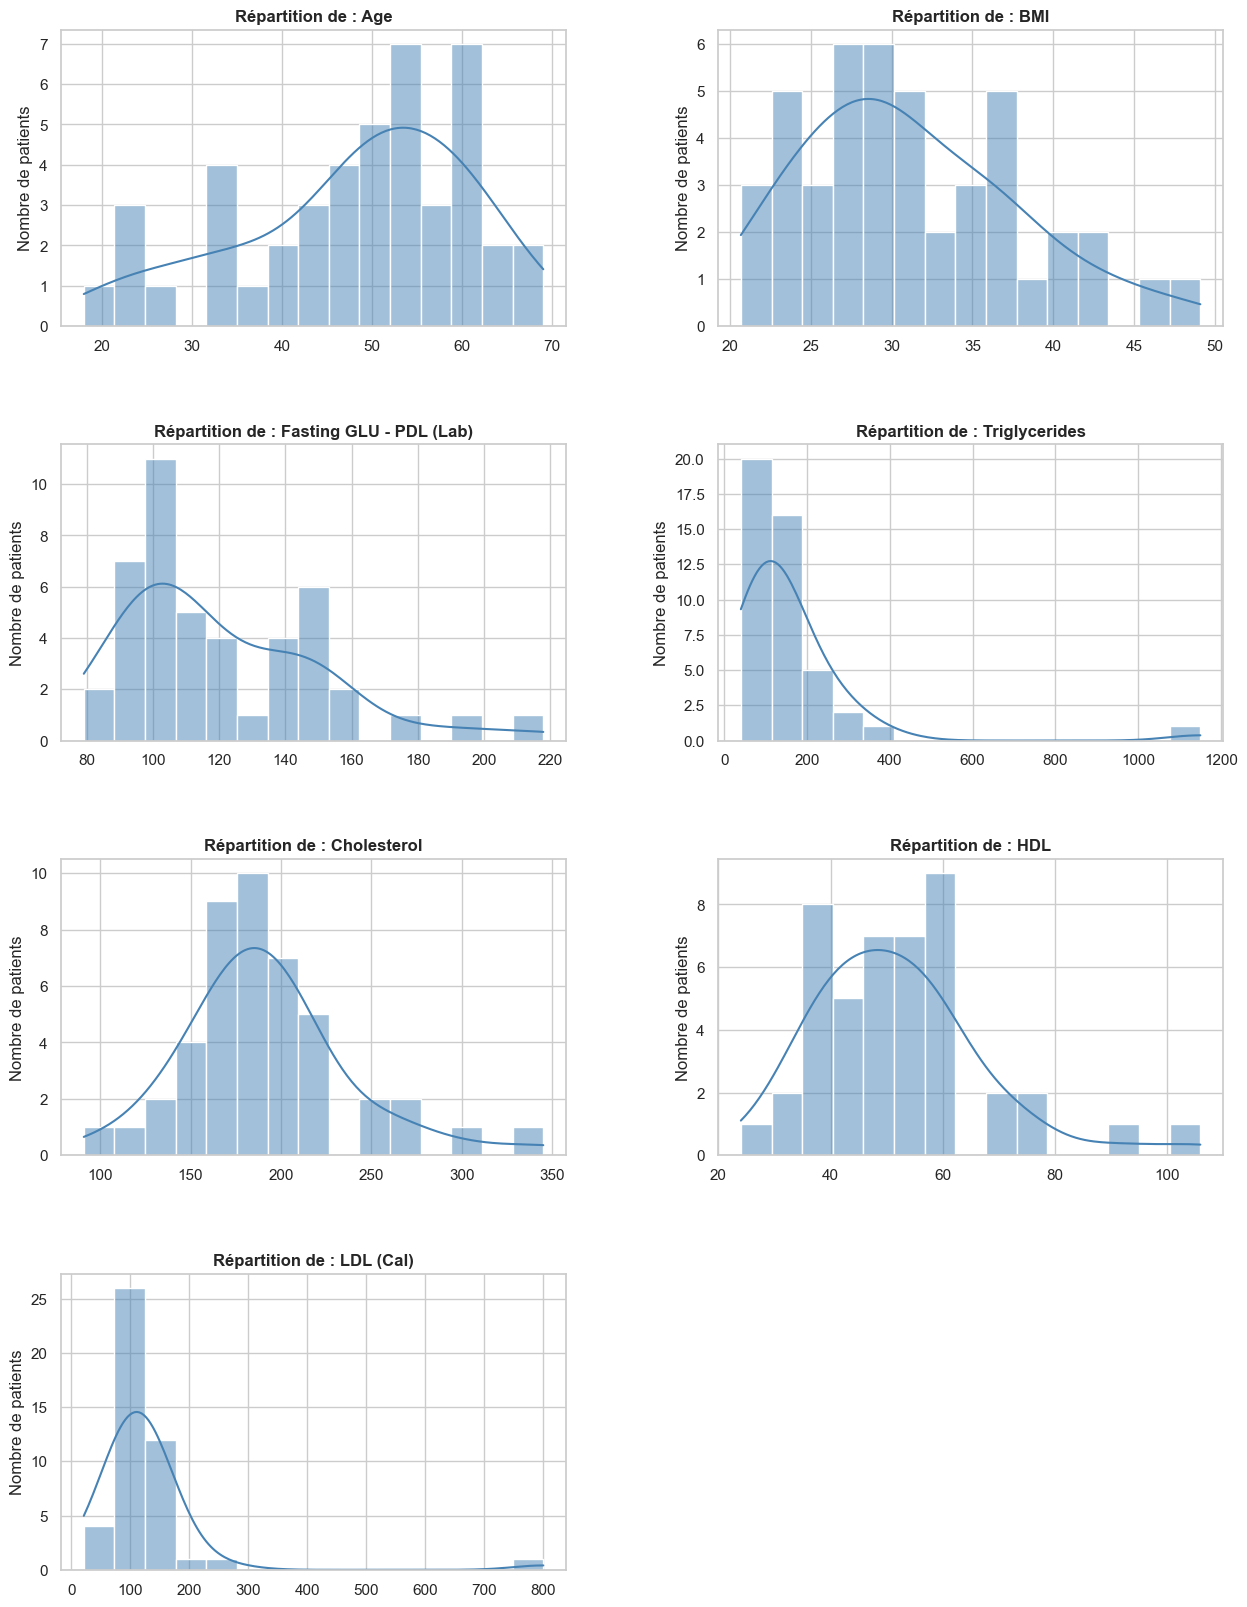

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style visuel
sns.set_theme(style="whitegrid")

# Définition des 7 variables strictement numériques
colonnes_numeriques = [
    "Age", 
    "BMI", 
    "Fasting GLU - PDL (Lab)", 
    "Triglycerides", 
    "Cholesterol", 
    "HDL", 
    "LDL (Cal)"
]

# Création du canevas (4 lignes, 2 colonnes = 8 emplacements)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
fig.subplots_adjust(hspace=0.4, wspace=0.3)
axes = axes.flatten()

# Tracé des histogrammes avec boucle
for i, col in enumerate(colonnes_numeriques):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color="steelblue", bins=15)
    axes[i].set_title(f'Répartition de : {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Nombre de patients')

# Suppression du 8ème graphique qui est désormais inutile (index 7)
fig.delaxes(axes[7])

# Affichage du rendu final
plt.show()

In [11]:
print(df.columns.tolist())

['subject', 'group', 'Age', 'Gender', 'BMI', 'Body weight ', 'Height ', 'Self-identify ', 'A1c PDL (Lab)', 'Fasting GLU - PDL (Lab)', 'Insulin ', 'Triglycerides', 'Cholesterol', 'HDL', 'Non HDL ', 'LDL (Cal)', 'VLDL (Cal)', 'Cho/HDL Ratio', 'Collection time PDL (Lab)', '#1 Contour Fingerstick GLU', 'Time (t)', ' #2 Contour Fingerstick GLU', 'Time (t).1', '#3 Contour Fingerstick GLU', 'Time (t).2']


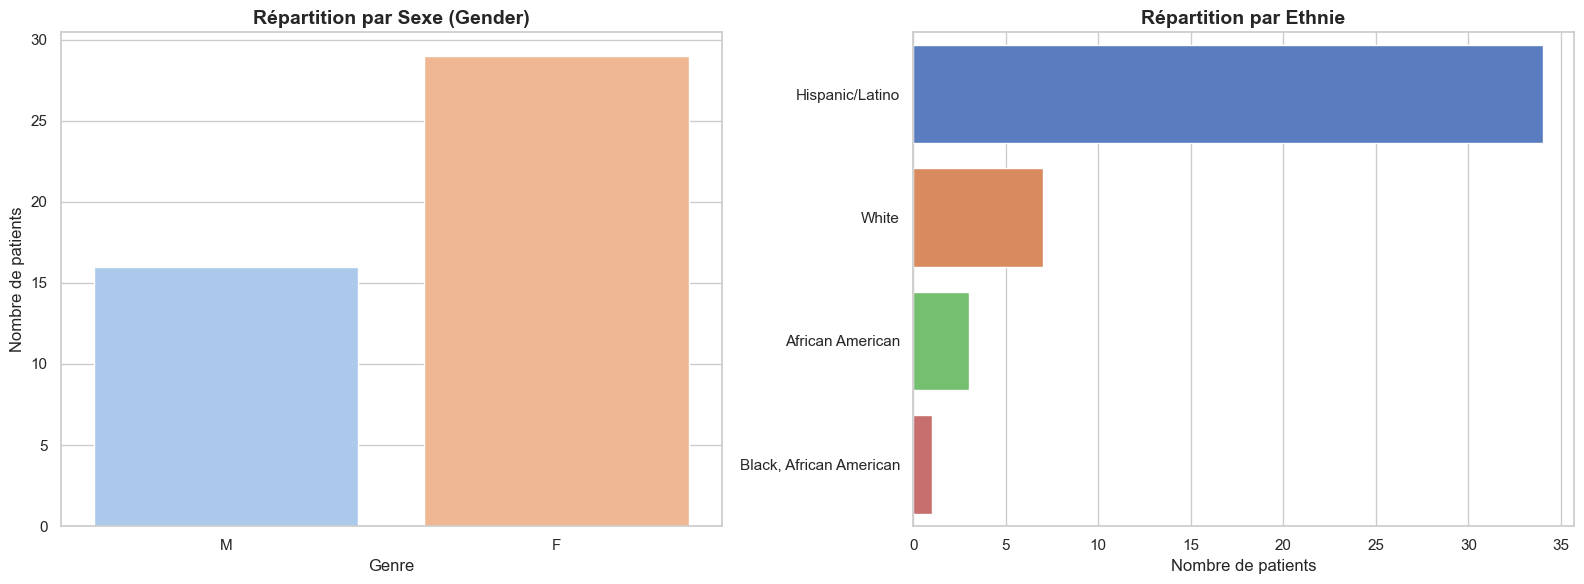

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. NETTOYAGE DES COLONNES (Supprime les espaces invisibles au début et à la fin)
df.columns = df.columns.str.strip()

# 2. Configuration du style visuel
sns.set_theme(style="whitegrid")

# 3. Création de la figure (1 ligne, 2 colonnes)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# --- Graphe 1 : Gender ---
sns.countplot(
    data=df, 
    x='Gender', 
    hue='Gender',
    ax=axes[0], 
    palette='pastel',
    legend=False
)
axes[0].set_title('Répartition par Sexe (Gender)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Nombre de patients')

# --- Graphe 2 : Ethnie (Le nom est maintenant propre, sans espace !) ---
nom_colonne_ethnie = 'Self-identify'

sns.countplot(
    data=df, 
    y=nom_colonne_ethnie, 
    hue=nom_colonne_ethnie,
    ax=axes[1], 
    palette='muted', 
    order=df[nom_colonne_ethnie].value_counts().index,
    legend=False
)
axes[1].set_title('Répartition par Ethnie', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nombre de patients')
axes[1].set_ylabel('')

# 4. Ajustement automatique et affichage
plt.tight_layout()
plt.show()

In [16]:
import pandas as pd

# Vérification instantanée de la présence de valeurs manquantes (NaN)
if df.isnull().values.any():
    print("Oui, il y a des valeurs manquantes.")
else:
    print("Aucune donnée manquante.")

Aucune donnée manquante.


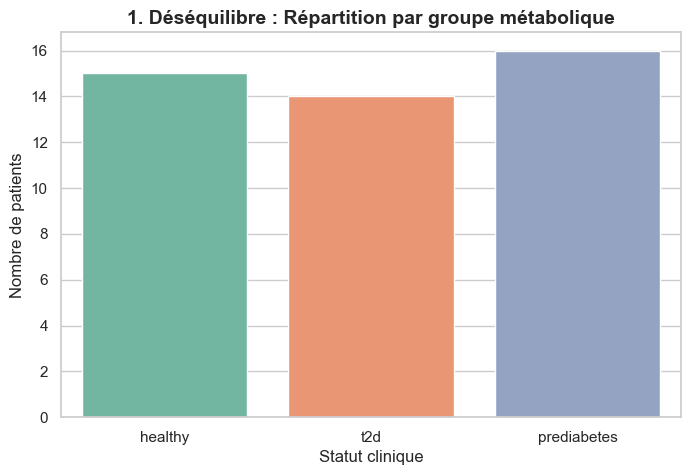

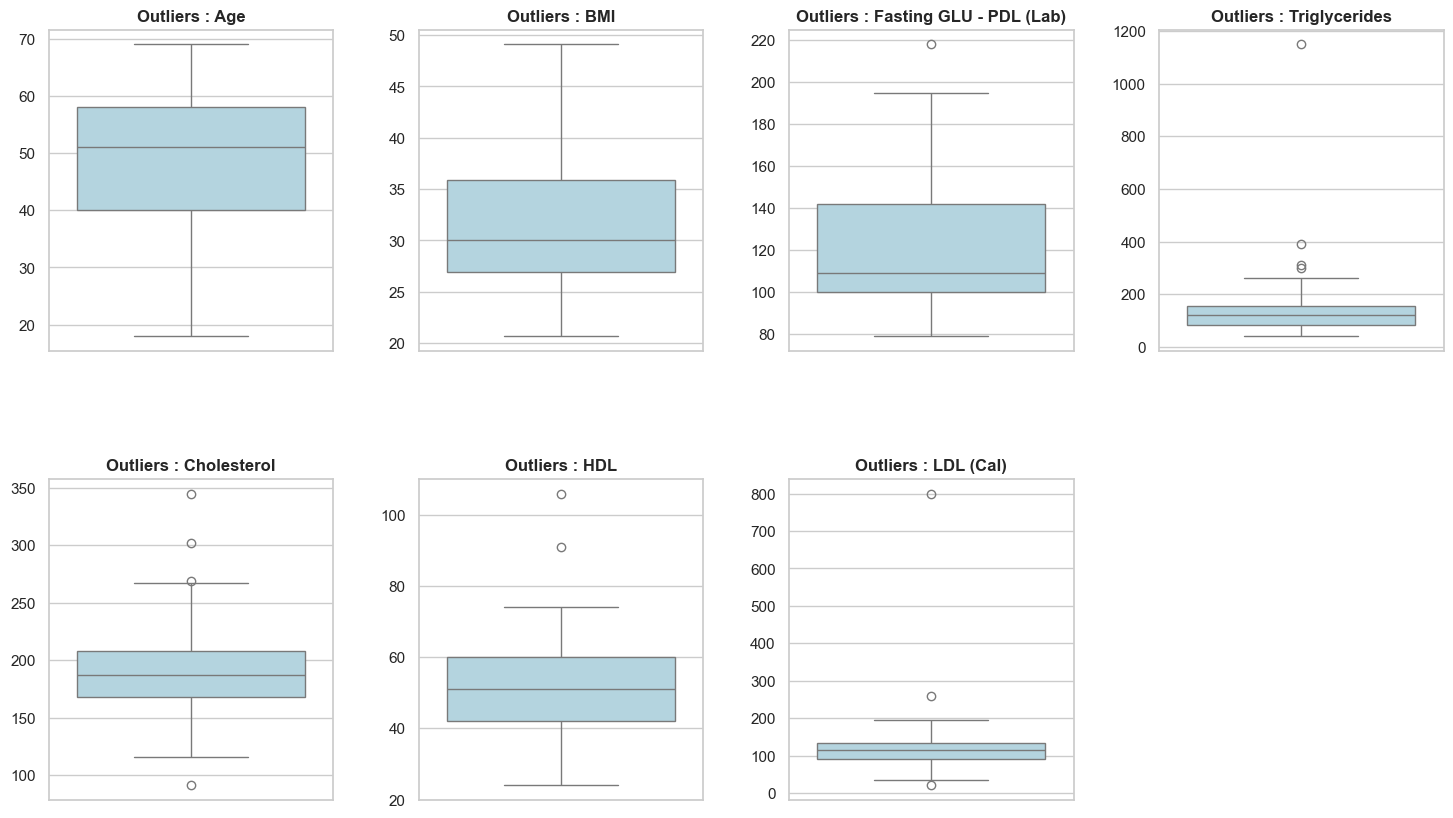

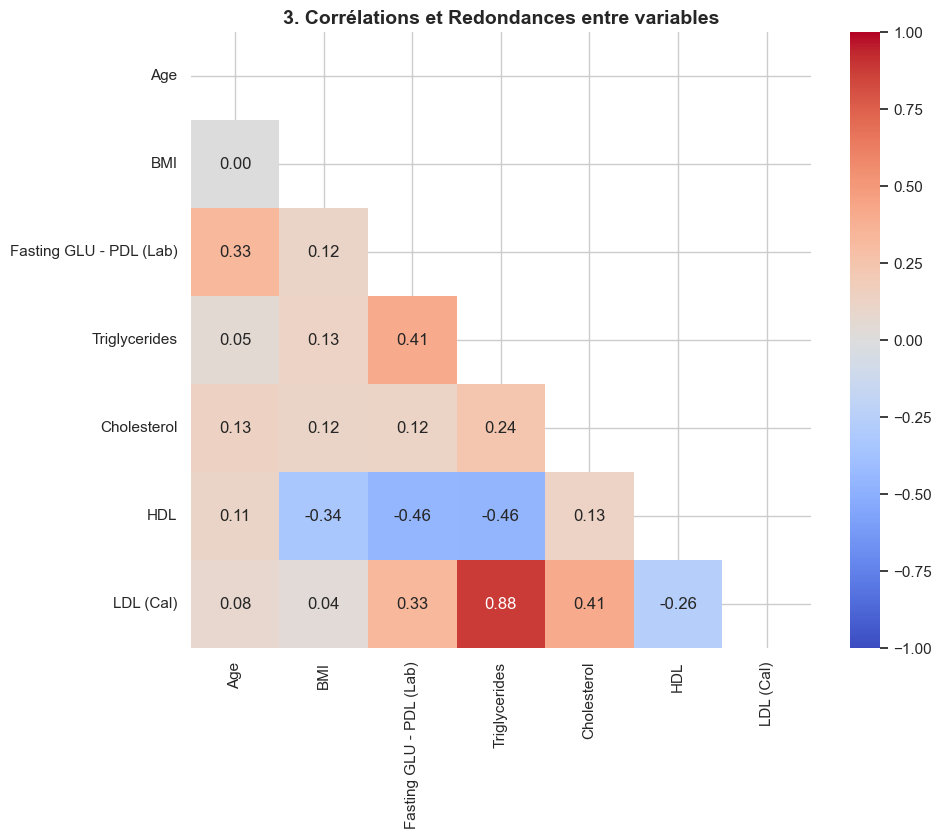

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuration visuelle
sns.set_theme(style="whitegrid")

# Définition de nos colonnes numériques d'intérêt
colonnes_numeriques = [
    "Age", "BMI", "Fasting GLU - PDL (Lab)", 
    "Triglycerides", "Cholesterol", "HDL", "LDL (Cal)"
]

# ==========================================
# 1. DÉSÉQUILIBRE DES CLASSES (Target)
# ==========================================
plt.figure(figsize=(8, 5))
# Vérifiez que votre colonne s'appelle bien 'group', sinon adaptez le nom
sns.countplot(data=df, x='group', hue='group', palette='Set2', legend=False)
plt.title('1. Déséquilibre : Répartition par groupe métabolique', fontsize=14, fontweight='bold')
plt.ylabel('Nombre de patients')
plt.xlabel('Statut clinique')
plt.show()


# ==========================================
# 2. VALEURS ABERRANTES (Boxplots)
# ==========================================
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 10))
fig.subplots_adjust(hspace=0.4, wspace=0.3)
axes = axes.flatten()

for i, col in enumerate(colonnes_numeriques):
    # Le boxplot affiche la médiane, les quartiles, et les points au-delà sont les outliers
    sns.boxplot(data=df, y=col, ax=axes[i], color="lightblue")
    axes[i].set_title(f'Outliers : {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('')

fig.delaxes(axes[7]) # On supprime la 8ème case vide
plt.show()


# ==========================================
# 3. CORRÉLATIONS ET REDONDANCES (Heatmap)
# ==========================================
plt.figure(figsize=(10, 8))

# On isole uniquement les colonnes numériques pour calculer la corrélation (évite les erreurs)
df_num = df[colonnes_numeriques]
matrice_corr = df_num.corr()

# Astuce de pro : on crée un masque pour cacher la moitié supérieure du tableau (qui est un miroir)
mask = np.triu(np.ones_like(matrice_corr, dtype=bool))

# Tracé de la carte de chaleur avec les valeurs chiffrées (annot=True)
sns.heatmap(
    matrice_corr, 
    mask=mask, 
    annot=True, 
    fmt=".2f", # 2 chiffres après la virgule
    cmap='coolwarm', # Bleu pour corrélation négative, Rouge pour positive
    vmin=-1, vmax=1 # Échelle stricte de -1 à 1
)
plt.title('3. Corrélations et Redondances entre variables', fontsize=14, fontweight='bold')
plt.show()